In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download \
-c challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:05<00:00, 54.4MB/s]



In [ ]:
!mkdir -p /content/drive/MyDrive/ML/assignment4

!mv challenges-in-representation-learning-facial-expression-recognition-challenge.zip \
/content/drive/MyDrive/ML/assignment4/

In [ ]:
!unzip "/content/drive/MyDrive/ML/assignment4/challenges-in-representation-learning-facial-expression-recognition-challenge.zip" \
-d "/content/drive/MyDrive/ML/assignment4/"

Archive:  /content/drive/MyDrive/ML/assignment4/challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: /content/drive/MyDrive/ML/assignment4/example_submission.csv  
  inflating: /content/drive/MyDrive/ML/assignment4/fer2013.tar.gz  
  inflating: /content/drive/MyDrive/ML/assignment4/icml_face_data.csv  
  inflating: /content/drive/MyDrive/ML/assignment4/test.csv  
  inflating: /content/drive/MyDrive/ML/assignment4/train.csv  


In [2]:
%cd /content/drive/MyDrive/ML/assignment4/


/content/drive/MyDrive/ML/assignment4


In [3]:
ls


challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
experiment.ipynb
fer2013.tar.gz
icml_face_data.csv
test.csv
train.csv
wandb/


In [4]:
!pip install wandb


In [ ]:
!nvidia-smi

Tue Jun 16 13:53:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
import wandb

In [19]:
wandb.login()

True

# Data Loading and Analyses

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb
from sklearn.model_selection import train_test_split
from PIL import Image

In [6]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

emotion_labels = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',4:'Sad',5:'Surprise',6:'Neutral'}
print(train_df['emotion'].value_counts().sort_index().rename(emotion_labels))

emotion
Angry       3995
Disgust      436
Fear        4097
Happy       7215
Sad         4830
Surprise    3171
Neutral     4965
Name: count, dtype: int64


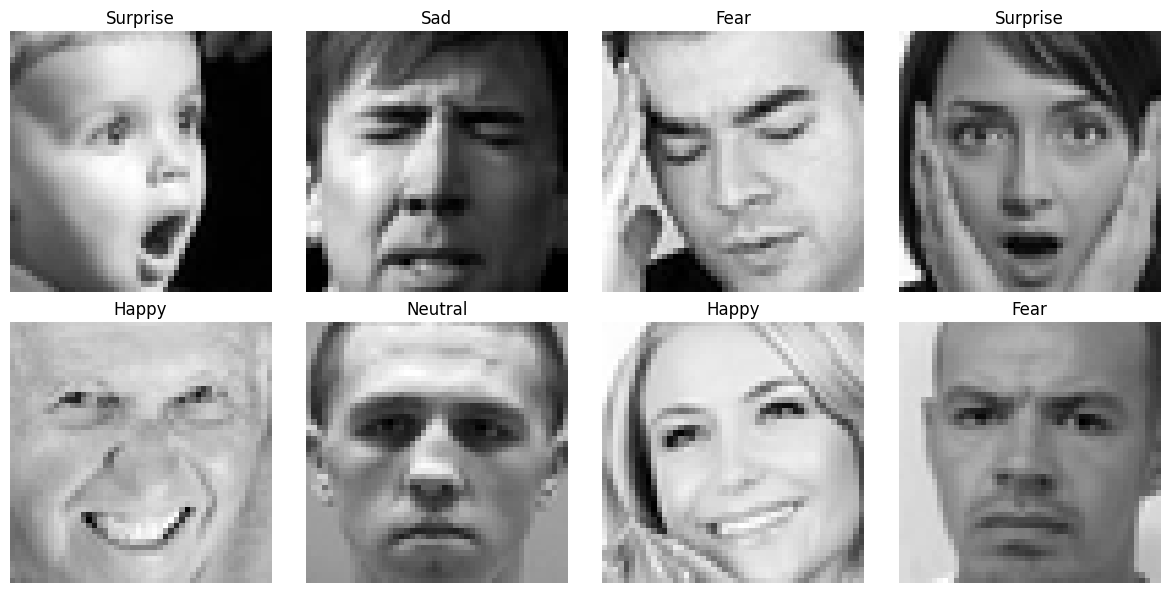

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    row = train_df.sample(1).iloc[0]
    img = np.fromstring(row['pixels'], sep=' ', dtype=np.uint8).reshape(48, 48)
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion_labels[row['emotion']])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Dataset and transforms

In [7]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None, is_test=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixels = np.fromstring(self.df.iloc[idx]['pixels'], sep=' ', dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            return image
        label = int(self.df.iloc[idx]['emotion'])
        return image, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data, val_data = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['emotion'])

train_dataset = FERDataset(train_data, transform=train_transform)
val_dataset   = FERDataset(val_data,   transform=val_transform)
test_dataset  = FERDataset(test_df,    transform=val_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


# Training utilities

In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, 100 * correct / total


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, 100 * correct / total


def run_experiment(model, config, run_name):
    wandb.init(project='fer-facial-expression', name=run_name, config=config)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 0))
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    for epoch in range(1, config['epochs'] + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = val_epoch(model, val_loader, criterion, device)
        scheduler.step()

        print(f"Epoch {epoch:02d}/{config['epochs']} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.2f}%")

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss': vl_loss,   'val_acc': vl_acc,
            'lr': scheduler.get_last_lr()[0]
        })

    wandb.finish()
    return model

# Architecture 1 - CNN baseline

In [ ]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 12 * 12, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


config_1 = {'epochs': 20, 'lr': 1e-3, 'weight_decay': 0}
model_1 = run_experiment(TinyCNN(), config_1, run_name='arch1-tiny-cnn-baseline')

Epoch 01/20 | Train Loss: 1.6397 Acc: 34.82% | Val Loss: 1.5338 Acc: 41.27%
Epoch 02/20 | Train Loss: 1.4763 Acc: 43.21% | Val Loss: 1.4191 Acc: 44.97%
Epoch 03/20 | Train Loss: 1.3939 Acc: 46.46% | Val Loss: 1.3479 Acc: 48.03%
Epoch 04/20 | Train Loss: 1.3290 Acc: 49.32% | Val Loss: 1.3098 Acc: 49.39%
Epoch 05/20 | Train Loss: 1.2816 Acc: 51.04% | Val Loss: 1.2938 Acc: 50.26%
Epoch 06/20 | Train Loss: 1.2522 Acc: 52.26% | Val Loss: 1.2600 Acc: 51.93%
Epoch 07/20 | Train Loss: 1.2203 Acc: 53.53% | Val Loss: 1.2317 Acc: 52.94%
Epoch 08/20 | Train Loss: 1.1872 Acc: 54.62% | Val Loss: 1.2386 Acc: 53.92%
Epoch 09/20 | Train Loss: 1.1652 Acc: 55.96% | Val Loss: 1.2092 Acc: 54.16%
Epoch 10/20 | Train Loss: 1.1419 Acc: 56.80% | Val Loss: 1.2081 Acc: 54.65%
Epoch 11/20 | Train Loss: 1.0961 Acc: 58.56% | Val Loss: 1.1890 Acc: 56.60%
Epoch 12/20 | Train Loss: 1.0782 Acc: 59.45% | Val Loss: 1.2120 Acc: 55.14%
Epoch 13/20 | Train Loss: 1.0667 Acc: 59.97% | Val Loss: 1.1839 Acc: 55.87%
Epoch 14/20 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,█████████▃▃▃▃▃▃▃▃▃▃▁
train_acc,▁▃▄▅▅▅▆▆▆▆▇▇▇▇▇█████
train_loss,█▆▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁
val_acc,▁▃▄▄▅▆▆▆▆▇█▇▇███▇▇██
val_loss,█▆▄▄▃▃▂▂▂▂▁▂▁▁▁▁▁▁▁▁
epoch,20
lr,0.00025
train_acc,62.85316
train_loss,0.99016
val_acc,56.9488


# Archirecture 2 - CNN with BatchNorm and Dropout

In [15]:
class MediumCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


no_aug_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_loader_no_aug = DataLoader(
    FERDataset(train_data, transform=no_aug_transform),
    batch_size=64, shuffle=True, num_workers=2
)

def run_experiment_no_aug(model, config, run_name):
    wandb.init(project='fer-facial-expression', name=run_name, config=config)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    for epoch in range(1, config['epochs'] + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader_no_aug, optimizer, criterion, device)
        vl_loss, vl_acc = val_epoch(model, val_loader, criterion, device)
        scheduler.step()

        print(f"Epoch {epoch:02d}/{config['epochs']} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.2f}%")

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss': vl_loss,   'val_acc': vl_acc,
            'lr': scheduler.get_last_lr()[0]
        })

    wandb.finish()
    return model


config_2 = {'epochs': 40, 'lr': 1e-3}
model_2 = run_experiment_no_aug(MediumCNN(), config_2, run_name='arch2-medium-cnn-bn-overfit-demo')

Epoch 01/40 | Train Loss: 1.7776 Acc: 28.72% | Val Loss: 1.5721 Acc: 39.60%
Epoch 02/40 | Train Loss: 1.5701 Acc: 37.71% | Val Loss: 1.4356 Acc: 44.76%
Epoch 03/40 | Train Loss: 1.4873 Acc: 41.47% | Val Loss: 1.3862 Acc: 46.64%
Epoch 04/40 | Train Loss: 1.4365 Acc: 43.78% | Val Loss: 1.3196 Acc: 48.21%
Epoch 05/40 | Train Loss: 1.3820 Acc: 45.74% | Val Loss: 1.3729 Acc: 45.59%
Epoch 06/40 | Train Loss: 1.3518 Acc: 46.76% | Val Loss: 1.2693 Acc: 49.29%
Epoch 07/40 | Train Loss: 1.3113 Acc: 48.39% | Val Loss: 1.2299 Acc: 52.70%
Epoch 08/40 | Train Loss: 1.2792 Acc: 49.50% | Val Loss: 1.2149 Acc: 54.72%
Epoch 09/40 | Train Loss: 1.2407 Acc: 51.07% | Val Loss: 1.2018 Acc: 54.62%
Epoch 10/40 | Train Loss: 1.2182 Acc: 51.94% | Val Loss: 1.2653 Acc: 52.87%
Epoch 11/40 | Train Loss: 1.1403 Acc: 54.90% | Val Loss: 1.1748 Acc: 55.97%
Epoch 12/40 | Train Loss: 1.1104 Acc: 55.70% | Val Loss: 1.1760 Acc: 55.63%
Epoch 13/40 | Train Loss: 1.0775 Acc: 56.89% | Val Loss: 1.1700 Acc: 56.22%
Epoch 14/40 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▇▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▃▅▆▇▇▆█▇█▇███▇▇▇████████▇█████▇██▇██
val_loss,▅▄▃▃▃▂▂▁▁▂▁▁▁▁▁▂▂▂▂▂▂▃▄▄▃▃▄▄▅▆▆▆▆▆▆▇▇███
epoch,40
lr,6e-05
train_acc,73.85634
train_loss,0.62817
val_acc,55.72971


# Architecture 3 - Deep CNN with augmentation and L2 regularization

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256),         nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


config_3 = {'epochs': 25, 'lr': 5e-4, 'weight_decay': 1e-4}
model_3 = run_experiment(DeepCNN(), config_3, run_name='arch3-deep-cnn-aug-regularized')

Epoch 01/25 | Train Loss: 1.7815 Acc: 26.19% | Val Loss: 1.6324 Acc: 34.31%
Epoch 02/25 | Train Loss: 1.5752 Acc: 38.77% | Val Loss: 1.4251 Acc: 44.20%
Epoch 03/25 | Train Loss: 1.4510 Acc: 43.99% | Val Loss: 1.3554 Acc: 48.14%
Epoch 04/25 | Train Loss: 1.3859 Acc: 46.64% | Val Loss: 1.2606 Acc: 51.38%
Epoch 05/25 | Train Loss: 1.3368 Acc: 48.58% | Val Loss: 1.2807 Acc: 51.79%
Epoch 06/25 | Train Loss: 1.3101 Acc: 49.99% | Val Loss: 1.2165 Acc: 53.88%
Epoch 07/25 | Train Loss: 1.2837 Acc: 50.55% | Val Loss: 1.2174 Acc: 52.87%
Epoch 08/25 | Train Loss: 1.2701 Acc: 51.54% | Val Loss: 1.1968 Acc: 54.93%
Epoch 09/25 | Train Loss: 1.2444 Acc: 52.50% | Val Loss: 1.1932 Acc: 57.12%
Epoch 10/25 | Train Loss: 1.2243 Acc: 53.36% | Val Loss: 1.1525 Acc: 57.68%
Epoch 11/25 | Train Loss: 1.1891 Acc: 54.75% | Val Loss: 1.1302 Acc: 57.85%
Epoch 12/25 | Train Loss: 1.1697 Acc: 55.24% | Val Loss: 1.1145 Acc: 58.45%
Epoch 13/25 | Train Loss: 1.1642 Acc: 55.46% | Val Loss: 1.1183 Acc: 58.59%
Epoch 14/25 

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,█████████▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁
train_acc,▁▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇████████
train_loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▄▅▅▅▆▆▆▇▇▇▇▇▇███████████
val_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,25
lr,0.00013
train_acc,59.60214
train_loss,1.06173
val_acc,61.79032


In [24]:
import torch
import torch.nn as nn

class BetterDeepCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.4),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [26]:
config = {
    'epochs': 60,
    'lr': 3e-4,
    'weight_decay': 5e-4
}

model = run_experiment(
    BetterDeepCNN(),
    config,
    run_name='better-deepcnn-gelu-gap'
)

epoch,▁▃▆█
lr,▁▁▁▁
train_acc,▁▃▇█
train_loss,█▆▂▁
val_acc,▁▅▇█
val_loss,█▄▂▁
epoch,4
lr,0.0003
train_acc,47.22889
train_loss,1.38036
val_acc,51.82863


Epoch 01/60 | Train Loss: 1.7952 Acc: 25.28% | Val Loss: 1.7145 Acc: 29.95%
Epoch 02/60 | Train Loss: 1.5885 Acc: 37.36% | Val Loss: 1.4133 Acc: 44.51%
Epoch 03/60 | Train Loss: 1.4251 Acc: 45.17% | Val Loss: 1.3416 Acc: 48.28%
Epoch 04/60 | Train Loss: 1.3535 Acc: 48.23% | Val Loss: 1.2371 Acc: 51.93%
Epoch 05/60 | Train Loss: 1.3029 Acc: 50.31% | Val Loss: 1.1921 Acc: 53.57%
Epoch 06/60 | Train Loss: 1.2659 Acc: 51.58% | Val Loss: 1.1460 Acc: 56.08%
Epoch 07/60 | Train Loss: 1.2450 Acc: 52.68% | Val Loss: 1.1234 Acc: 57.09%
Epoch 08/60 | Train Loss: 1.2139 Acc: 53.60% | Val Loss: 1.1187 Acc: 56.91%
Epoch 09/60 | Train Loss: 1.1960 Acc: 54.32% | Val Loss: 1.0978 Acc: 58.93%
Epoch 10/60 | Train Loss: 1.1792 Acc: 55.60% | Val Loss: 1.0734 Acc: 59.35%
Epoch 11/60 | Train Loss: 1.1384 Acc: 56.81% | Val Loss: 1.0538 Acc: 60.12%
Epoch 12/60 | Train Loss: 1.1256 Acc: 57.39% | Val Loss: 1.0414 Acc: 60.36%
Epoch 13/60 | Train Loss: 1.1092 Acc: 58.01% | Val Loss: 1.0217 Acc: 61.23%
Epoch 14/60 

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
lr,██████▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
train_loss,█▆▅▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▅▆▇▇▇▇▇▇▇▇▇██████████████████████████
val_loss,█▅▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,60
lr,0.0
train_acc,66.42155
train_loss,0.89918
val_acc,65.09927


# Architecture 4 - CNN + LSTM hybrid

    def __init__(
        self,
        num_classes=7,
        cnn_channels=(32, 64),   # <-- TUNE: e.g. (16,32), (32,64), (64,128)
        lstm_hidden=128,          # <-- TUNE: e.g. 64, 128, 256
        lstm_layers=2,            # <-- TUNE: 1, 2, or 3
        bidirectional=True,       # <-- TUNE: True (BiLSTM) or False
        dropout=0.3,              # <-- TUNE: 0.0 to 0.5
    ):

In [9]:
import torch
import torch.nn as nn


class CNN_LSTM(nn.Module):
    def __init__(
        self,
        num_classes=7,
        cnn_channels=(64, 128),   # tested (32,64), (64,128)
        lstm_hidden=128,
        lstm_layers=3,            # tested 2, 3
        bidirectional=True,
        dropout=0.3,
    ):
        super().__init__()

        c1, c2 = cnn_channels

        self.cnn = nn.Sequential(
            nn.Conv2d(1, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )


        lstm_input_size = c2 * 12

        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        lstm_out_size = lstm_hidden * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 1, 3)
        x = x.reshape(B, H, C * W)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.classifier(out)


model_test = CNN_LSTM()
dummy = torch.zeros(4, 1, 48, 48)
print('Output shape:', model_test(dummy).shape)
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Output shape: torch.Size([4, 7])
Trainable parameters: 2,605,191


In [11]:
config_4 = {
    'epochs': 30,
    'lr': 5e-4,
    'weight_decay': 1e-4,

    'cnn_channels': (64, 128),
    'lstm_hidden': 128,
    'lstm_layers': 3,
    'bidirectional': True,
    'dropout': 0.3,
}

model_4 = CNN_LSTM(
    cnn_channels=config_4['cnn_channels'],
    lstm_hidden=config_4['lstm_hidden'],
    lstm_layers=config_4['lstm_layers'],
    bidirectional=config_4['bidirectional'],
    dropout=config_4['dropout'],
)

model_4 = run_experiment(model_4, config_4, run_name='arch4-cnn-lstm-hybrid')

epoch,▁▂▄▅▇█
lr,▁▁▁▁▁▁
train_acc,▁▄▆▇▇█
train_loss,█▅▃▂▂▁
val_acc,▁▄▆▆▇█
val_loss,█▅▄▃▂▁
epoch,6
lr,0.0005
train_acc,47.18631
train_loss,1.36251
val_acc,49.46012


Epoch 01/30 | Train Loss: 1.7404 Acc: 28.97% | Val Loss: 1.6396 Acc: 34.06%
Epoch 02/30 | Train Loss: 1.5904 Acc: 37.36% | Val Loss: 1.5118 Acc: 40.30%
Epoch 03/30 | Train Loss: 1.4889 Acc: 41.83% | Val Loss: 1.4232 Acc: 43.64%
Epoch 04/30 | Train Loss: 1.4334 Acc: 44.02% | Val Loss: 1.3862 Acc: 44.90%
Epoch 05/30 | Train Loss: 1.3808 Acc: 46.31% | Val Loss: 1.3504 Acc: 47.23%
Epoch 06/30 | Train Loss: 1.3514 Acc: 47.55% | Val Loss: 1.3149 Acc: 48.87%
Epoch 07/30 | Train Loss: 1.3196 Acc: 48.67% | Val Loss: 1.2719 Acc: 50.19%
Epoch 08/30 | Train Loss: 1.3022 Acc: 49.28% | Val Loss: 1.2535 Acc: 51.27%
Epoch 09/30 | Train Loss: 1.2761 Acc: 50.38% | Val Loss: 1.2279 Acc: 52.14%
Epoch 10/30 | Train Loss: 1.2558 Acc: 51.45% | Val Loss: 1.2080 Acc: 53.43%
Epoch 11/30 | Train Loss: 1.2106 Acc: 53.15% | Val Loss: 1.1661 Acc: 55.59%
Epoch 12/30 | Train Loss: 1.1955 Acc: 53.85% | Val Loss: 1.1648 Acc: 54.89%
Epoch 13/30 | Train Loss: 1.1785 Acc: 54.71% | Val Loss: 1.1519 Acc: 55.63%
Epoch 14/30 

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train_loss,█▇▆▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▄▅▅▅▆▆▇▆▇▇▇▇▇▇▇▇██████████
val_loss,█▇▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch,30
lr,6e-05
train_acc,61.03801
train_loss,1.02465
val_acc,60.95437


done


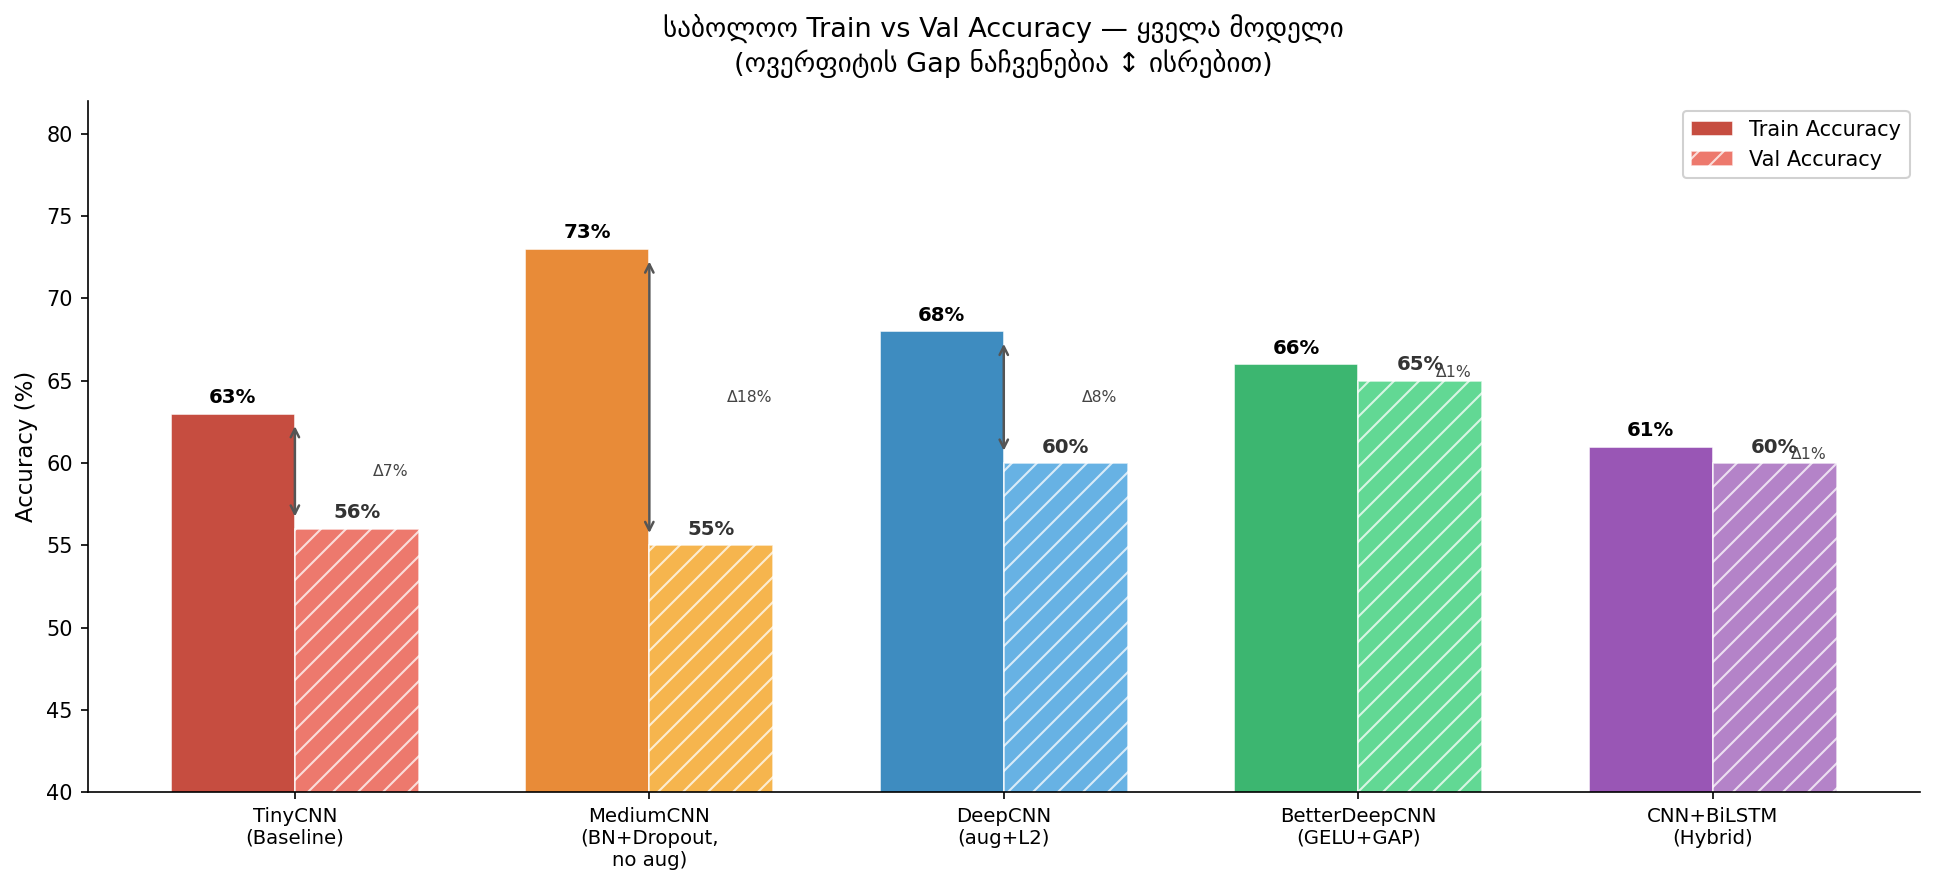

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

models = [
    'TinyCNN\n(Baseline)',
    'MediumCNN\n(BN+Dropout,\nno aug)',
    'DeepCNN\n(aug+L2)',
    'BetterDeepCNN\n(GELU+GAP)',
    'CNN+BiLSTM\n(Hybrid)',
]

train_accs = [63, 73, None, 66, 61]
val_accs   = [56, 55, None, 65, 60]

train_accs[2] = 68
val_accs[2]   = 60

COLORS_TRAIN = ['#c0392b','#e67e22','#2980b9','#27ae60','#8e44ad']
COLORS_VAL   = ['#e74c3c','#f39c12','#3498db','#2ecc71','#9b59b6']

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars_train = ax.bar(x - w/2, train_accs, width=w,
                    color=COLORS_TRAIN, edgecolor='white', linewidth=0.8,
                    label='Train Accuracy', alpha=0.9)
bars_val   = ax.bar(x + w/2, val_accs,   width=w,
                    color=COLORS_VAL,   edgecolor='white', linewidth=0.8,
                    label='Val Accuracy', alpha=0.75, hatch='//')

for bar, v in zip(bars_train, train_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{v}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
for bar, v in zip(bars_val, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{v}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#333')

for i, (tr, vl) in enumerate(zip(train_accs, val_accs)):
    gap = tr - vl
    mid_x = x[i]
    ax.annotate('', xy=(mid_x, vl + 0.5), xytext=(mid_x, tr - 0.5),
                arrowprops=dict(arrowstyle='<->', color='#555', lw=1.2))
    ax.text(mid_x + 0.22, (tr + vl)/2, f'Δ{gap}%',
            fontsize=7.5, color='#444', va='center')

ax.set_title('საბოლოო Train vs Val Accuracy — ყველა მოდელი\n'
             '(ოვერფიტის Gap ნაჩვენებია ↕ ისრებით)',
             fontsize=13, pad=14)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9.5)
ax.set_ylim(40, 82)
ax.legend(fontsize=10, framealpha=0.9)


plt.tight_layout()
print("done")